# GDP Analysis and Visualizations

This notebook explores the GDP dataset in `gdp.csv`, separates country-level records from World Bank aggregate groups, and creates reusable plots saved in the `figures/` folder.


In [1]:
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

from gdp_analysis import (
    load_data,
    plot_world_trend,
    plot_latest_top_countries,
    plot_major_economy_trends,
    plot_absolute_change,
    plot_yoy_growth,
    plot_top_country_heatmap,
    write_summary_tables,
)

sns.set_theme(style="whitegrid", context="notebook")


## 1. Load the Data

In [2]:
df = load_data()
latest_year = int(df["Year"].max())
earliest_year = int(df["Year"].min())

print(f"Rows: {len(df):,}")
print(f"Series: {df['Country Name'].nunique():,}")
print(f"Year range: {earliest_year}-{latest_year}")
print(f"Missing values: {int(df.isna().sum().sum())}")

df.head()


Rows: 11,507
Series: 256
Year range: 1960-2016
Missing values: 0


,Country Name,Country Code,Year,Value,GDP Trillion USD,Is Aggregate
0,Arab World,ARB,1968,2.576068e+10,0.025761,True
1,Arab World,ARB,1969,2.843420e+10,0.028434,True
2,Arab World,ARB,1970,3.138550e+10,0.031385,True
3,Arab World,ARB,1971,3.642691e+10,0.036427,True
4,Arab World,ARB,1972,4.331606e+10,0.043316,True


## 2. Basic Data Quality Checks

In [3]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique(),
})
quality_summary


,dtype,missing_values,unique_values
Country Name,object,0,256
Country Code,object,0,256
Year,int64,0,57
Value,float64,0,11398
GDP Trillion USD,float64,0,11398
Is Aggregate,bool,0,2


In [4]:
records_per_year = df.groupby("Year")["Country Name"].nunique().reset_index(name="series_count")
records_per_year.tail(10)


,Year,series_count
47,2007,251
48,2008,250
49,2009,249
50,2010,250
51,2011,250
52,2012,246
53,2013,247
54,2014,245
55,2015,244
56,2016,236


## 3. Separate Countries from Aggregate Groups

The dataset includes individual countries and aggregate regions/income groups such as `World`, `High income`, and `European Union`. Rankings below use country-only rows to avoid mixing countries with aggregates.


In [5]:
country_df = df[~df["Is Aggregate"]].copy()
aggregate_df = df[df["Is Aggregate"]].copy()

print(f"Country-level rows: {len(country_df):,}")
print(f"Aggregate rows: {len(aggregate_df):,}")
print(f"Country/economy series: {country_df['Country Name'].nunique():,}")


Country-level rows: 9,201
Aggregate rows: 2,306
Country/economy series: 210


## 4. World GDP Trend

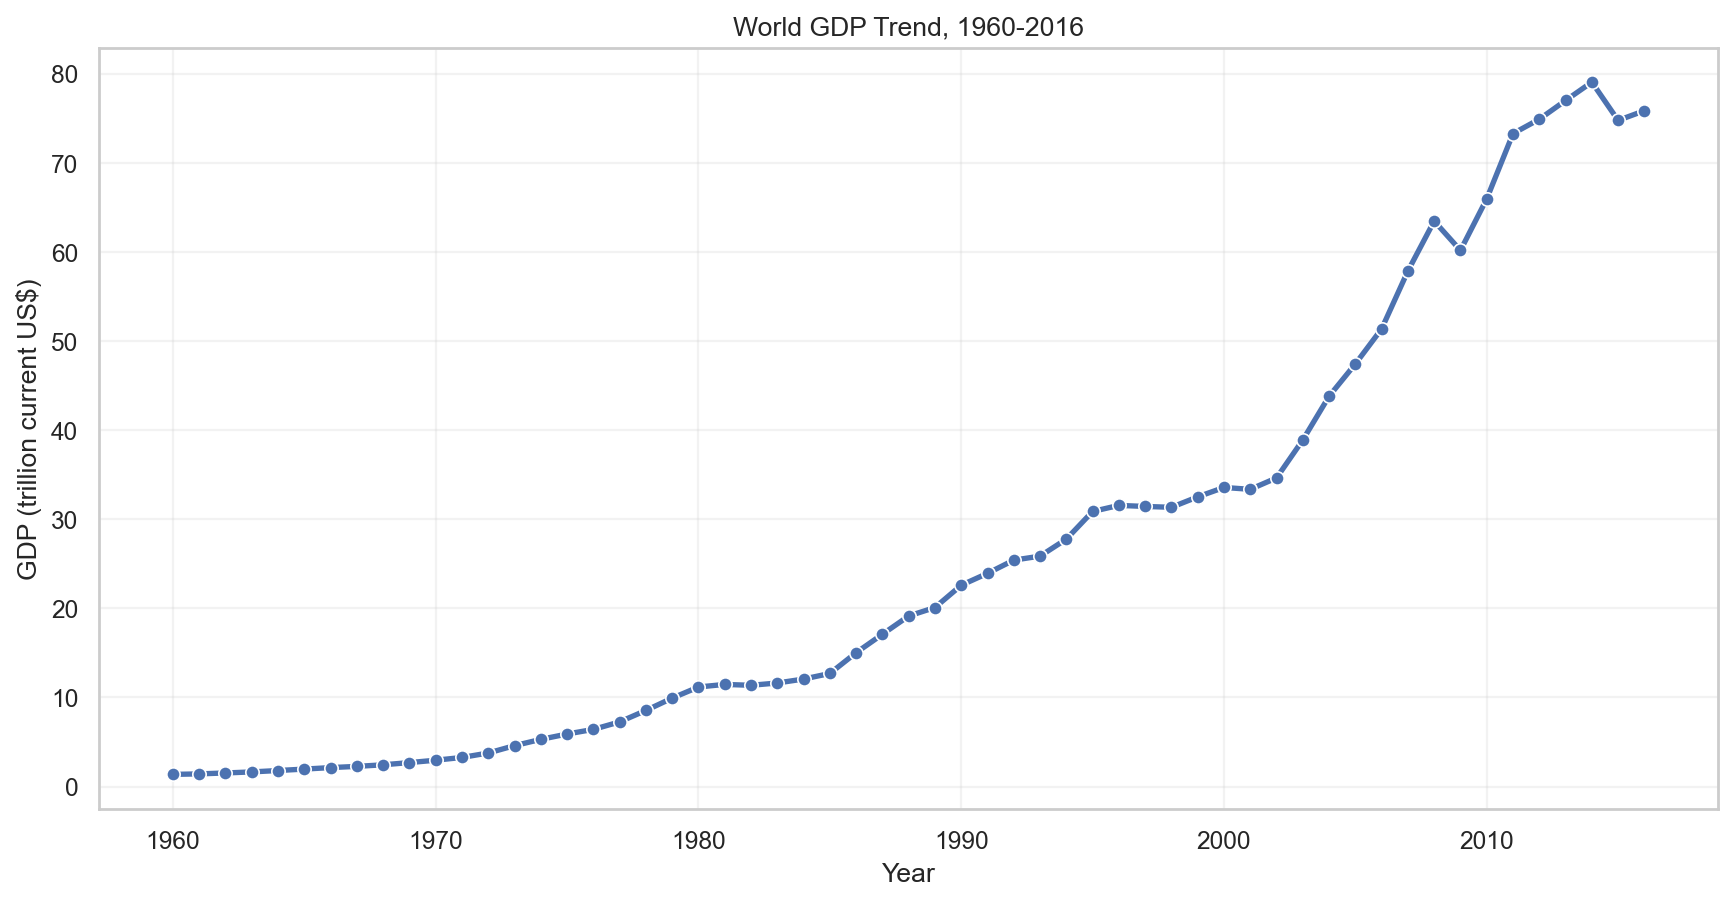

In [6]:
world_plot = plot_world_trend(df)
display(Image(filename=str(world_plot)))


## 5. Top Country GDPs in the Latest Year

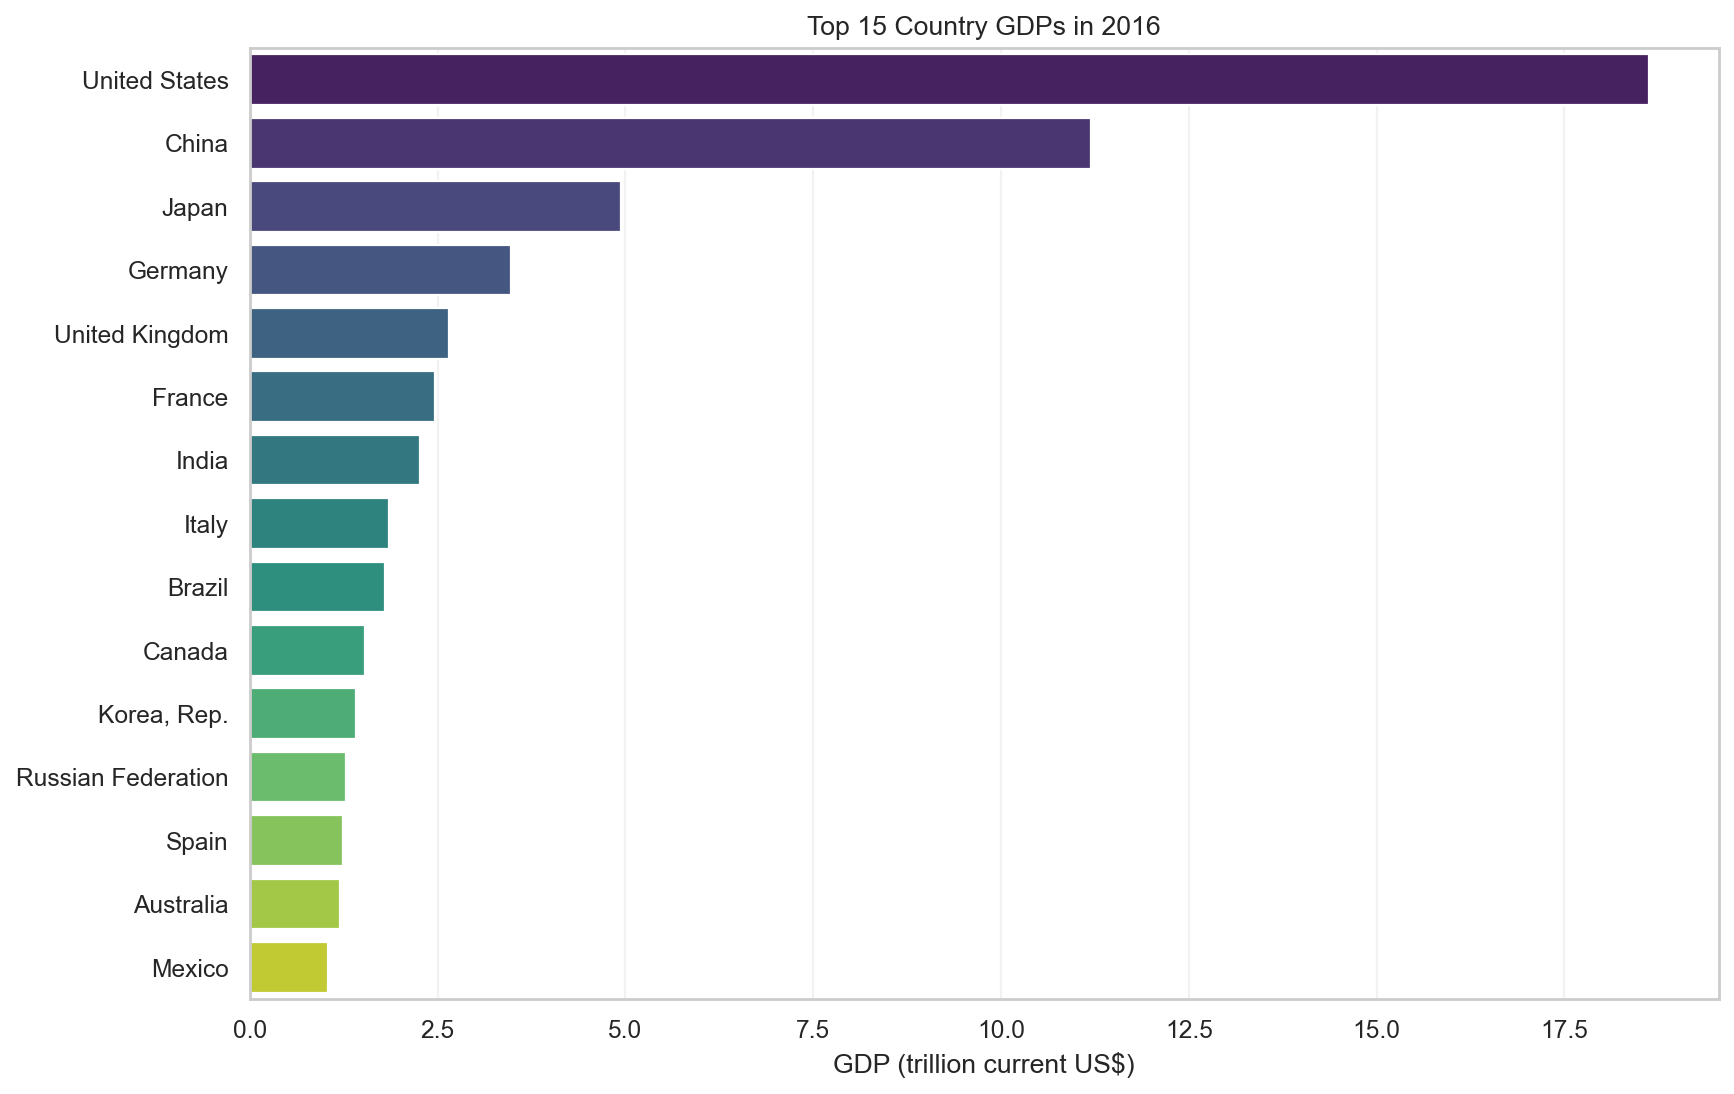

,Country Name,Country Code,Year,GDP Trillion USD
11085,United States,USA,2016,18.62
4102,China,CHN,2016,11.20
6582,Japan,JPN,2016,4.94
5443,Germany,DEU,2016,3.48
11028,United Kingdom,GBR,2016,2.65
5225,France,FRA,2016,2.47
6130,India,IND,2016,2.26
6468,Italy,ITA,2016,1.86
3469,Brazil,BRA,2016,1.80
3862,Canada,CAN,2016,1.53


In [7]:
top_plot, latest_top_15 = plot_latest_top_countries(df, latest_year)
display(Image(filename=str(top_plot)))
latest_top_15[["Country Name", "Country Code", "Year", "GDP Trillion USD"]].round(2)


## 6. GDP Trends for Major Economies

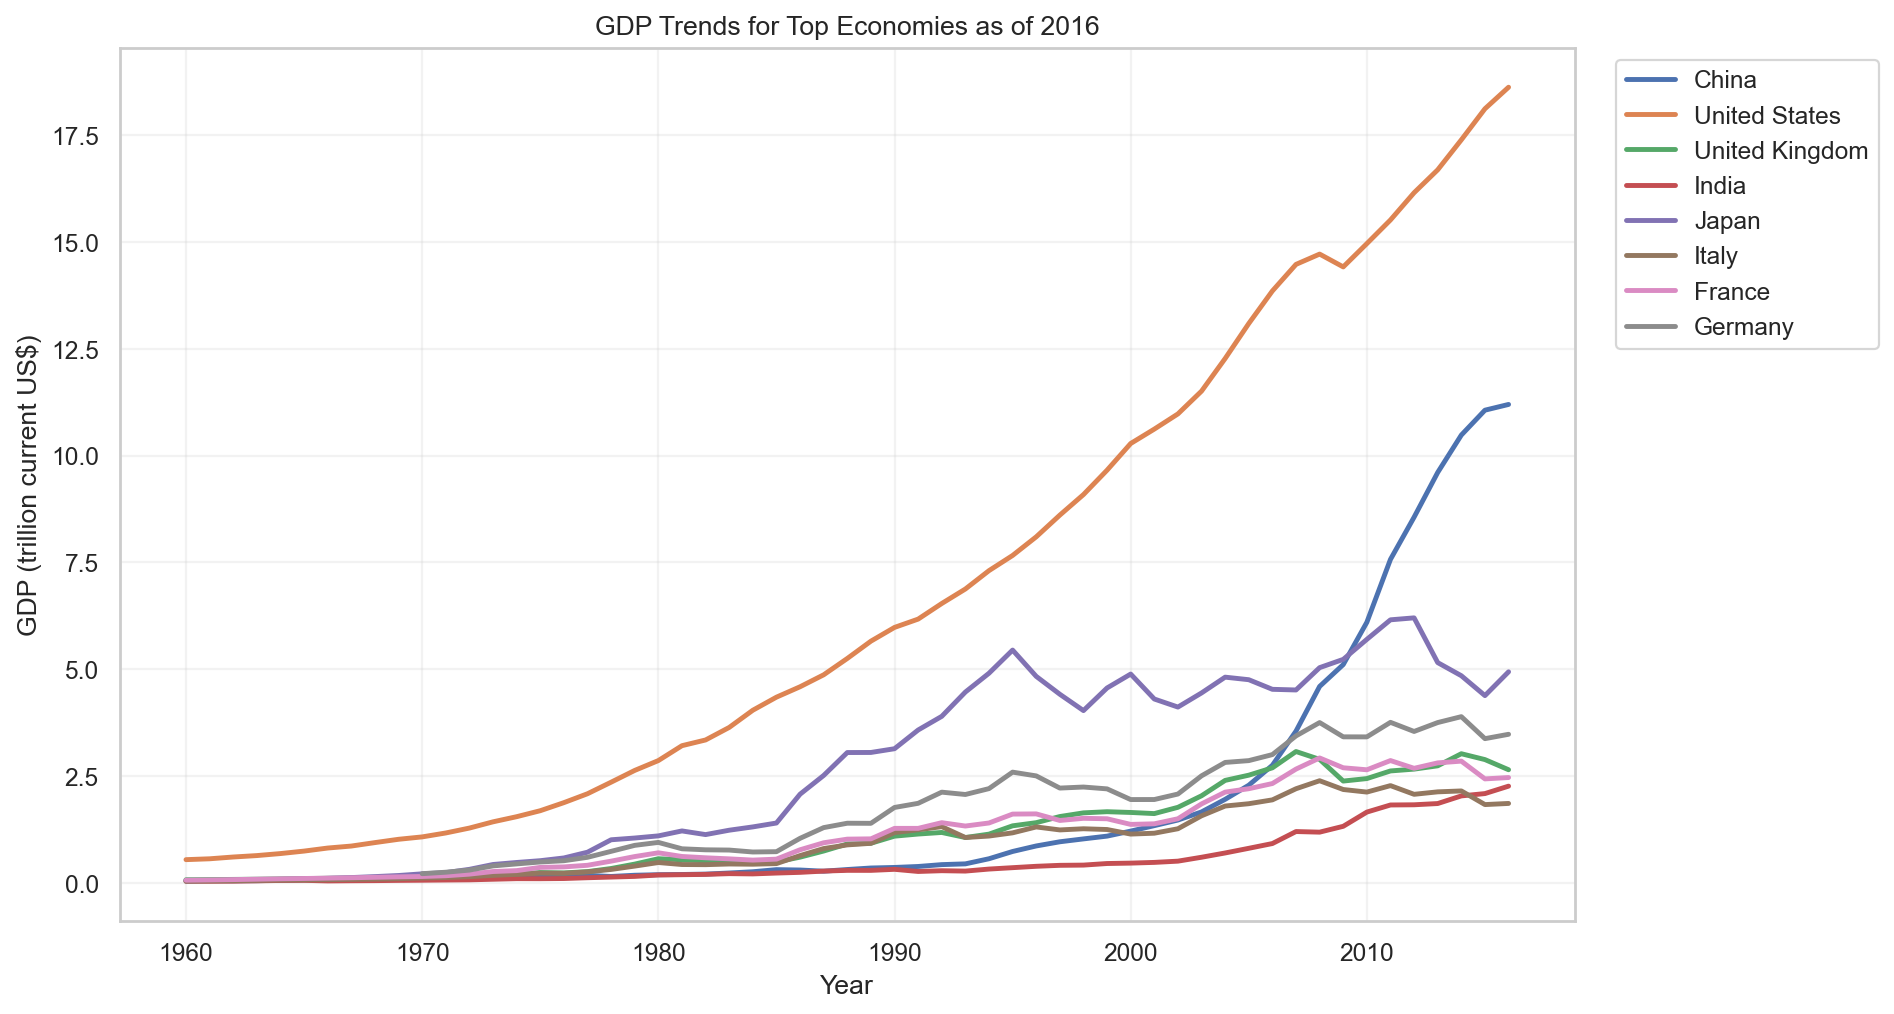

In [8]:
major_trend_plot = plot_major_economy_trends(df, latest_year)
display(Image(filename=str(major_trend_plot)))


## 7. Largest GDP Increases from 2000 to 2016

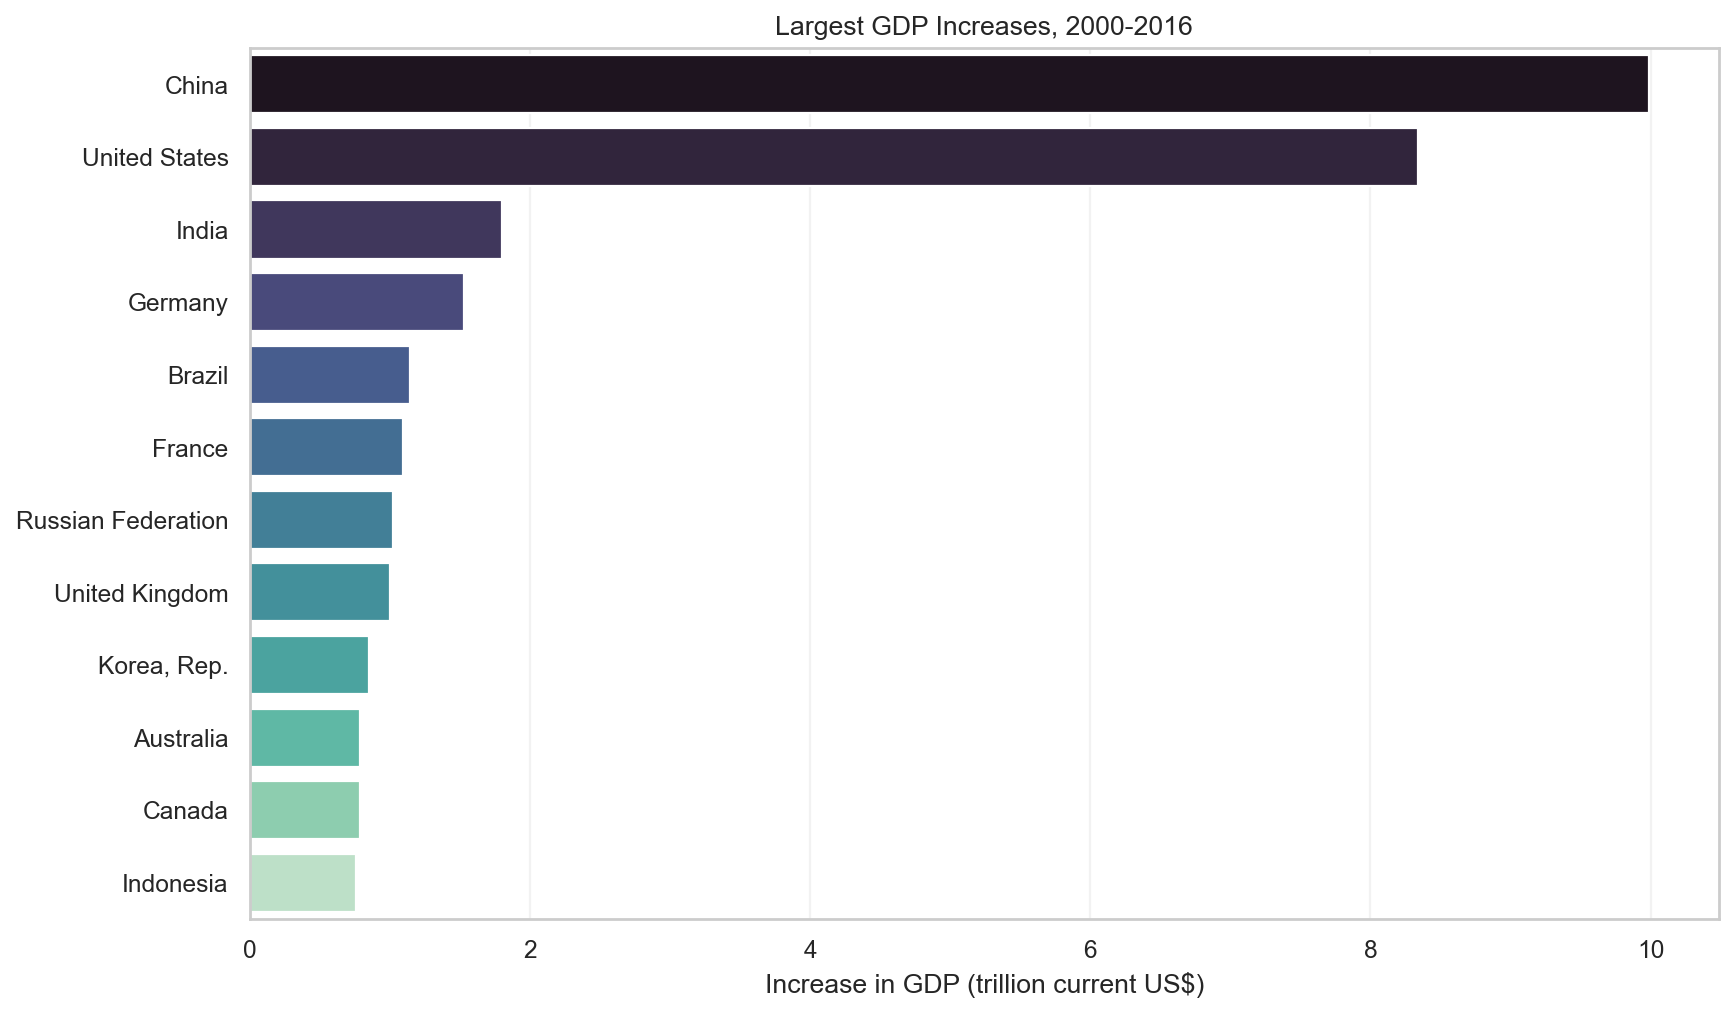

Year,Country Name,Country Code,Change Trillion USD
0,China,CHN,9.99
1,United States,USA,8.34
2,India,IND,1.80
3,Germany,DEU,1.53
4,Brazil,BRA,1.14
5,France,FRA,1.10
6,Russian Federation,RUS,1.02
7,United Kingdom,GBR,1.00
8,"Korea, Rep.",KOR,0.85
9,Australia,AUS,0.79


In [9]:
increase_plot, largest_increases = plot_absolute_change(df, 2000, latest_year)
display(Image(filename=str(increase_plot)))
largest_increases[["Country Name", "Country Code", "Change Trillion USD"]].round(2)


## 8. Year-over-Year GDP Growth

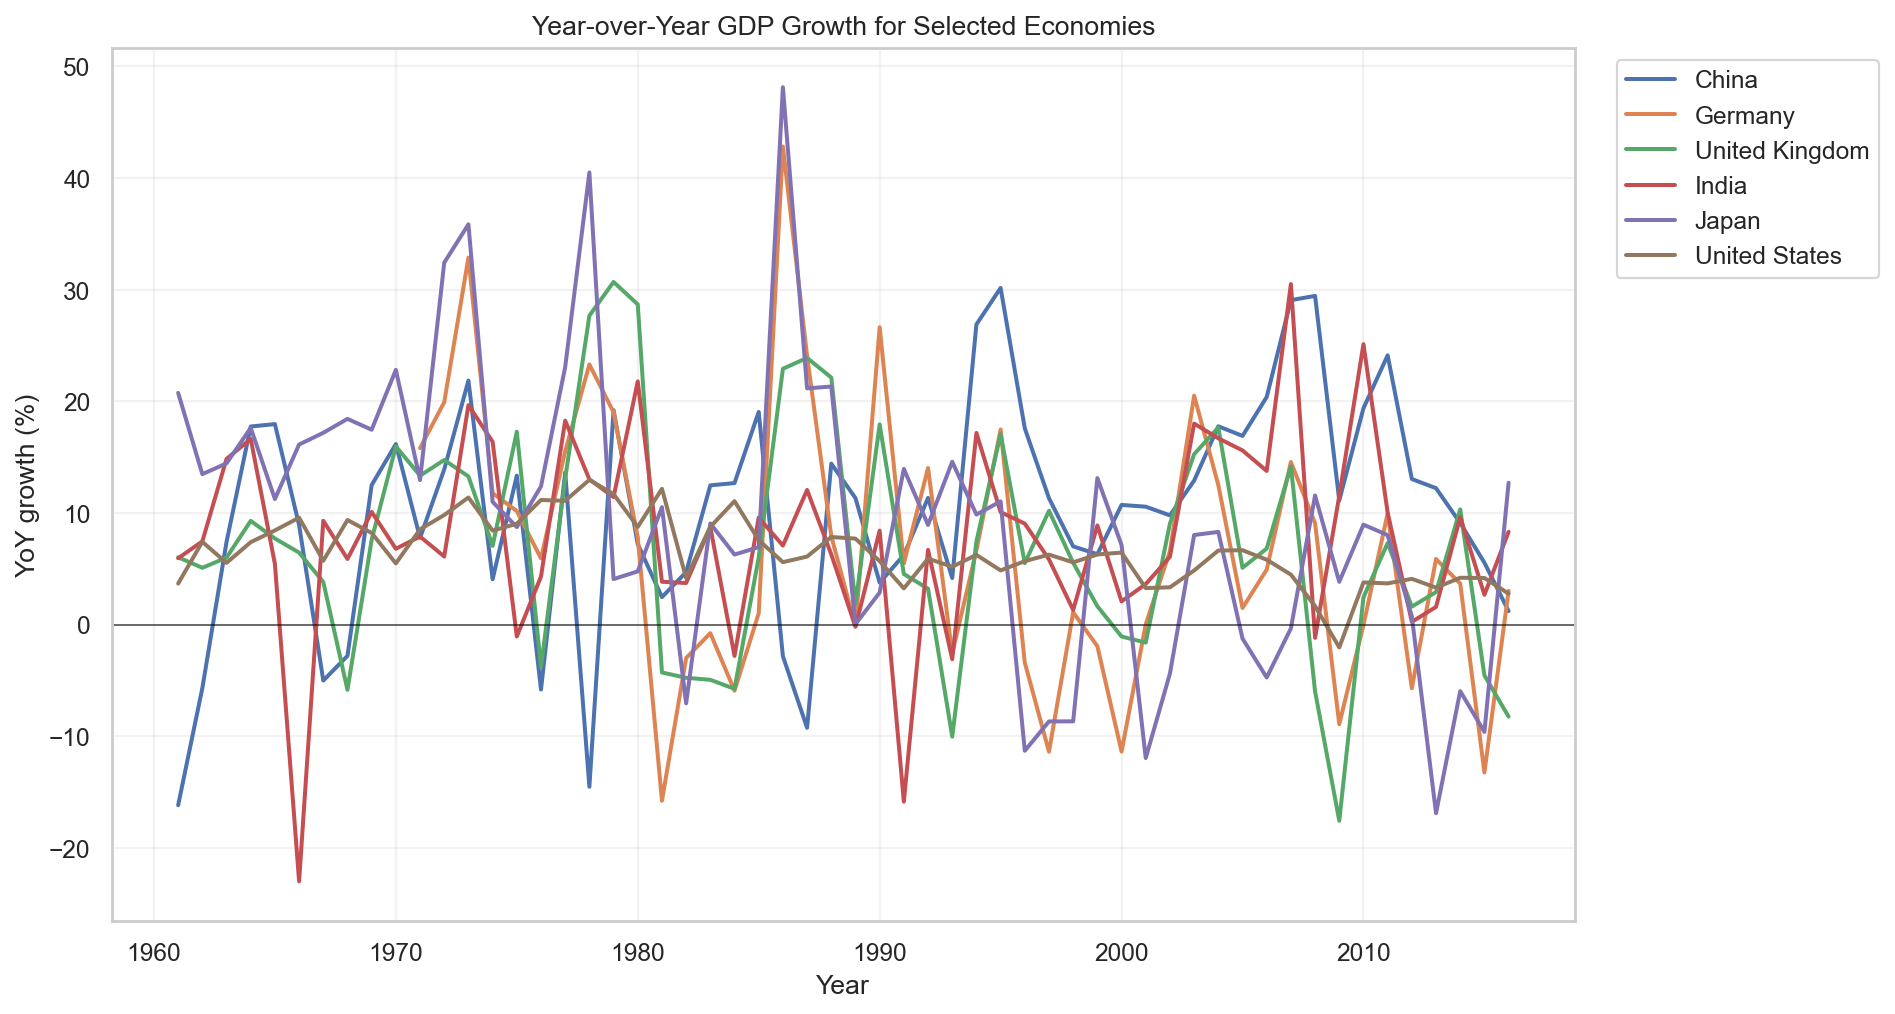

In [10]:
growth_plot = plot_yoy_growth(df)
display(Image(filename=str(growth_plot)))


## 9. GDP Heatmap for Top Countries

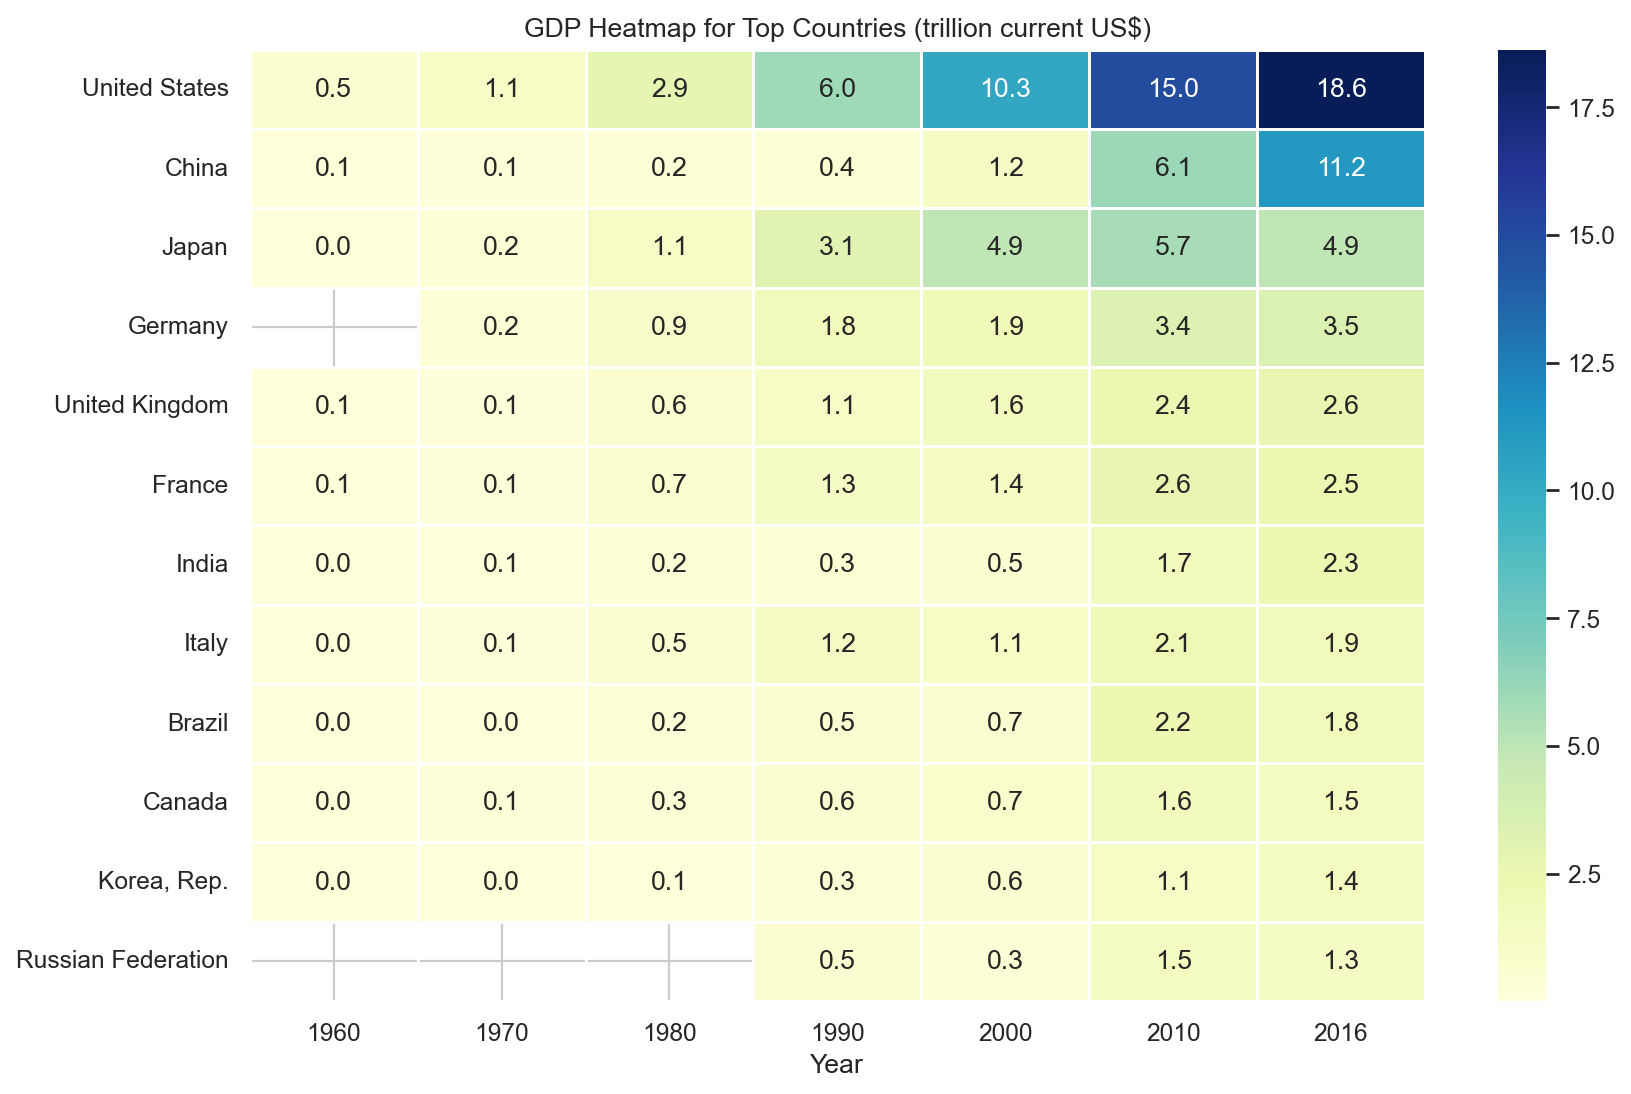

In [11]:
heatmap_plot = plot_top_country_heatmap(df, latest_year)
display(Image(filename=str(heatmap_plot)))


## 10. Save Summary Tables

In [12]:
write_summary_tables(latest_top_15, largest_increases)
print("Saved latest top countries to summary_tables/latest_top_15_countries.csv")
print("Saved largest GDP increases to summary_tables/largest_gdp_increases_2000_2016.csv")


Saved latest top countries to summary_tables/latest_top_15_countries.csv
Saved largest GDP increases to summary_tables/largest_gdp_increases_2000_2016.csv


## Key Takeaways

- The dataset covers 1960-2016 and contains no missing values in the core columns.
- The latest year in this file is 2016, not the current year.
- Country rankings should exclude World Bank aggregate groups to avoid comparing countries with regions or income categories.
- The United States, China, Japan, Germany, and the United Kingdom are the top five country-level GDPs in 2016 in this dataset.
- China shows the largest absolute GDP increase from 2000 to 2016 among country-level rows.
